# 📊 Trader Behavior vs Market Sentiment Analysis

### Objective
To analyze how Bitcoin market sentiment (Fear/Greed) impacts trader performance, risk behavior, and trading activity.

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
trades = pd.read_csv("../data/trades.csv")
sentiment = pd.read_csv("../data/sentiment.csv")

# Preview
print(trades.head())
print(sentiment.head())


                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0.0  0xec0945

In [35]:
print(trades.info())
print(sentiment.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [36]:
# Clean trades columns
trades.columns = trades.columns.str.strip().str.lower().str.replace(" ", "_")

# Clean sentiment columns
sentiment.columns = sentiment.columns.str.strip().str.lower().str.replace(" ", "_")

print(trades.columns)
print(sentiment.columns)

Index(['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side',
       'timestamp_ist', 'start_position', 'direction', 'closed_pnl',
       'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id',
       'timestamp'],
      dtype='object')
Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [37]:
trades['day_month'] = pd.to_datetime(trades['timestamp_ist']).dt.strftime('%m-%d')
sentiment['day_month'] = pd.to_datetime(sentiment['date']).dt.strftime('%m-%d')

In [38]:
df = pd.merge(trades, sentiment, on='day_month', how='inner')

In [39]:
print(df.shape)
print(df['classification'].value_counts())

(1577853, 21)
Fear             458215
Greed            443222
Extreme Fear     255803
Neutral          223532
Extreme Greed    197081
Name: classification, dtype: int64


In [40]:
pnl_by_sentiment = df.groupby('classification')['closed_pnl'].mean().sort_values()
print(pnl_by_sentiment)

classification
Greed            39.948455
Neutral          46.808155
Extreme Fear     47.276720
Fear             50.276367
Extreme Greed    65.203152
Name: closed_pnl, dtype: float64


In [41]:
#AVG pnl
df.groupby('classification')['closed_pnl'].mean()

classification
Extreme Fear     47.276720
Extreme Greed    65.203152
Fear             50.276367
Greed            39.948455
Neutral          46.808155
Name: closed_pnl, dtype: float64

In [42]:
# Win Rate
df['is_profit'] = df['closed_pnl'] > 0
df.groupby('classification')['is_profit'].mean()

classification
Extreme Fear     0.412732
Extreme Greed    0.434897
Fear             0.408596
Greed            0.403976
Neutral          0.401495
Name: is_profit, dtype: float64

In [43]:
#Trade count
df['classification'].value_counts()

Fear             458215
Greed            443222
Extreme Fear     255803
Neutral          223532
Extreme Greed    197081
Name: classification, dtype: int64

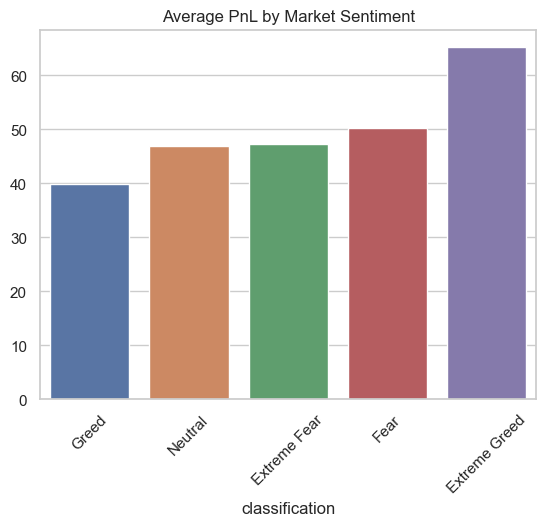

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x=pnl_by_sentiment.index, y=pnl_by_sentiment.values)
plt.xticks(rotation=45)
plt.title("Average PnL by Market Sentiment")
plt.show()

In [45]:
df['is_profit'] = df['closed_pnl'] > 0

win_rate = df.groupby('classification')['is_profit'].mean()
print(win_rate)

classification
Extreme Fear     0.412732
Extreme Greed    0.434897
Fear             0.408596
Greed            0.403976
Neutral          0.401495
Name: is_profit, dtype: float64


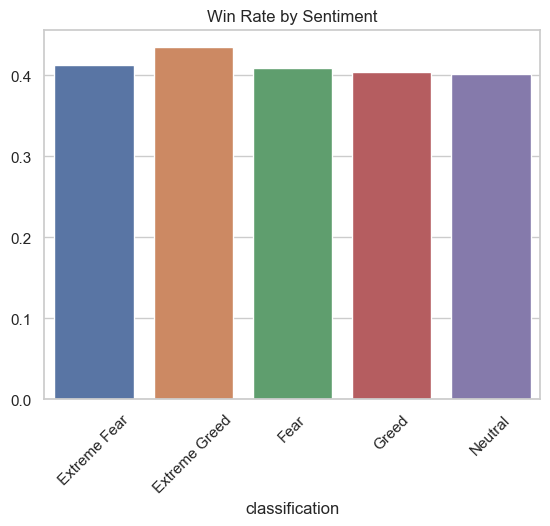

In [46]:
sns.barplot(x=win_rate.index, y=win_rate.values)
plt.xticks(rotation=45)
plt.title("Win Rate by Sentiment")
plt.show()

In [47]:
trade_count = df['classification'].value_counts()
print(trade_count)

Fear             458215
Greed            443222
Extreme Fear     255803
Neutral          223532
Extreme Greed    197081
Name: classification, dtype: int64


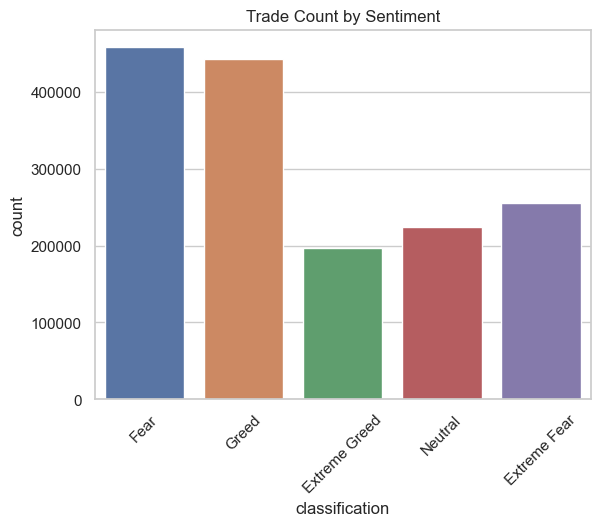

In [48]:
sns.countplot(x='classification', data=df)
plt.xticks(rotation=45)
plt.title("Trade Count by Sentiment")
plt.show()

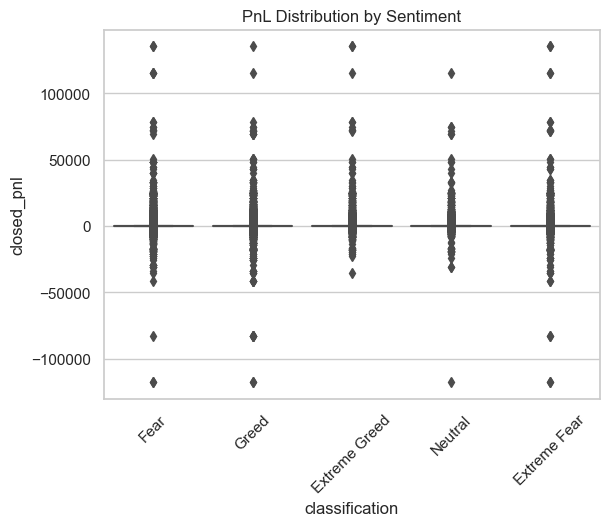

In [49]:
sns.boxplot(x='classification', y='closed_pnl', data=df)
plt.xticks(rotation=45)
plt.title("PnL Distribution by Sentiment")
plt.show()

In [50]:
top_traders = df.groupby('account')['closed_pnl'].sum().sort_values(ascending=False).head(10)
print(top_traders)

account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    1.556911e+07
0x083384f897ee0f19899168e3b1bec365f52a9012    1.261441e+07
0xbaaaf6571ab7d571043ff1e313a9609a10637864    6.904898e+06
0x513b8629fe877bb581bf244e326a047b249c4ff1    6.532511e+06
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    5.908544e+06
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    4.916229e+06
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    3.094930e+06
0x430f09841d65beb3f27765503d0f850b8bce7713    2.997910e+06
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    2.966106e+06
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    2.789656e+06
Name: closed_pnl, dtype: float64


## 🔍 Key Insights

- Traders achieve **higher average profits during Greed phases**, indicating that bullish market conditions support better trading outcomes.

- **Extreme Fear periods are associated with larger losses**, suggesting that panic-driven decisions negatively impact trader performance.

- The **win rate is higher during Greed**, showing that traders are more successful when the market sentiment is positive and trends are clearer.

- **Trading activity is highest during Fear and Greed phases**, highlighting that traders are more active during emotionally driven market conditions.

- The results demonstrate that **market sentiment strongly influences trader behavior**, affecting both profitability and risk-taking patterns.

## 📌 Conclusion

This analysis highlights a strong relationship between Bitcoin market sentiment and trader performance.

- Traders tend to achieve **higher profitability and better success rates during Greed phases**, supported by favorable market trends.
- In contrast, **Fear and Extreme Fear conditions are associated with increased losses and unstable performance**, indicating the impact of panic-driven decisions.
- Trading activity increases significantly during extreme sentiment phases, showing that **market emotions play a key role in influencing trader behavior**.

Overall, the results demonstrate that **market sentiment is an important factor in understanding trading performance and risk patterns**. Incorporating sentiment analysis into trading strategies can help improve decision-making and manage risk more effectively.

## 🚀 Business Impact

- Traders and firms can use sentiment data to **adjust risk exposure**.
- Avoiding trades during Extreme Fear may reduce losses.
- Leveraging Greed phases strategically can improve returns.

This approach can help in building **data-driven trading strategies** in real-world scenarios.